In [3]:
import sys
import os
from collections import defaultdict
import pandas as pd
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt
from glmpca import glmpca
from itertools import combinations
import torch
from torch.serialization import add_safe_globals, safe_globals
from gaston.neural_net import GASTON


import sys
from importlib import reload

import gaston
from gaston import neural_net,cluster_plotting, dp_related, segmented_fit, restrict_spots, model_selection
from gaston import binning_and_plotting, isodepth_scaling, run_slurm_scripts, parse_adata
from gaston import spatial_gene_classification, plot_cell_types, filter_genes, process_NN_output

import seaborn as sns
import math

add_safe_globals([GASTON])

In [2]:
df = pd.read_parquet("./skin_A1_16um_data/spatial/tissue_positions.parquet")
df.to_csv("./skin_A1_16um_data/spatial/tissue_positions_list.csv", index=False)  
df

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_016um_00000_00000-1,0,0,0,22513.350704,25064.874342
1,s_016um_00000_00001-1,0,0,1,22513.776583,25032.949219
2,s_016um_00000_00002-1,0,0,2,22514.202461,25001.024098
3,s_016um_00000_00003-1,0,0,3,22514.628339,24969.098978
4,s_016um_00000_00004-1,0,0,4,22515.054218,24937.173859
...,...,...,...,...,...,...
175556,s_016um_00418_00414-1,0,418,414,36034.087933,12026.244872
175557,s_016um_00418_00415-1,0,418,415,36034.513583,11994.320154
175558,s_016um_00418_00416-1,0,418,416,36034.939233,11962.395437
175559,s_016um_00418_00417-1,0,418,417,36035.364883,11930.470721


In [2]:
data_folder='skin_A1_16um_data' # folder with filtered_feature_bc_matrix.h5ad
spot_umi_threshold=0 # filter out cells with low UMIs
folder_to_save='skin_A1_16um_data' # NAME OF FOLDER TO SAVE DATA

########################################################

adata=sq.read.visium(data_folder)
sc.pp.filter_cells(adata, min_counts=spot_umi_threshold)
adata.obsm["spatial"] = np.asarray(adata.obsm["spatial"], dtype=float)

gene_labels=adata.var.index.to_numpy()
counts_mat=np.array(adata.X.todense())
coords_mat=np.copy(adata.obsm["spatial"])
coords_mat[:,1] *= -1

# make sure counts_mat is NxG and coords_mat is Nx2
if counts_mat.shape[0] != coords_mat.shape[0]:
    counts_mat=counts_mat.T

/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/squidpy/read/_read.py:82: DtypeWarning: Columns (1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  coords = pd.read_csv(
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
# save matrices
np.save(f'{folder_to_save}/counts_mat.npy', counts_mat)
np.save(f'{folder_to_save}/coords_mat.npy', coords_mat)
np.save(f'{folder_to_save}/gene_labels.npy', gene_labels)

In [3]:
counts_mat.shape, coords_mat.shape, gene_labels.shape

((78516, 18085), (78516, 2), (18085,))

In [4]:
use_RGB=True # set to False if you do not want to use RGB as features

# CODE to compute R,G,B mean from RGB image
if use_RGB:
    rgb_mean=parse_adata.use_RGB(adata)

calculating RGB


  0%|          | 0/78516 [00:00<?, ?/s]/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read

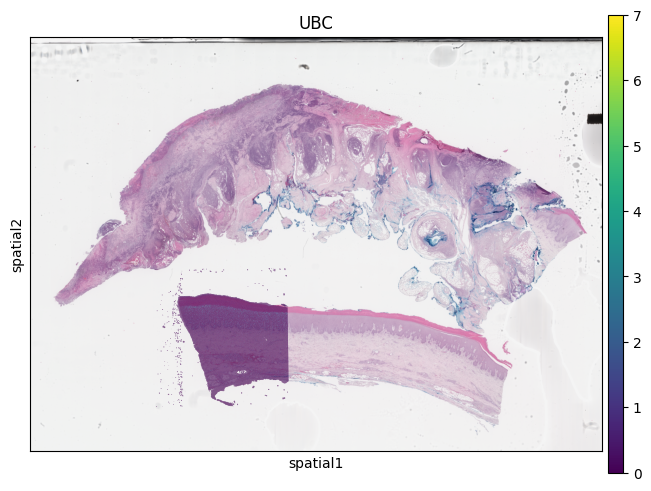

In [5]:
sq.pl.spatial_scatter(
    adata,
    color="UBC",           # Replace with your gene of interest
)

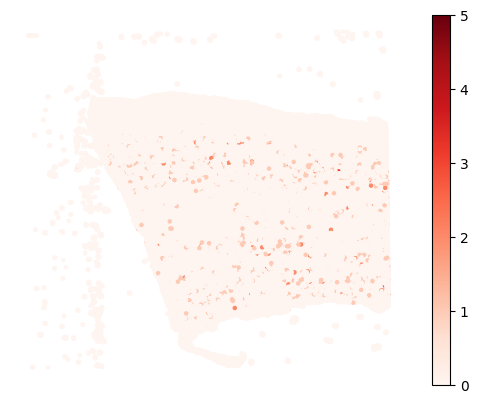

In [6]:
plt.scatter(coords_mat[:,0], coords_mat[:,1], c=counts_mat[:,8760], cmap='Reds',s=5)
plt.axis('off')
plt.colorbar()

In [3]:
# num_dims=5
# clip=10 # have to clip values to be very small!

# A = parse_adata.get_top_pearson_residuals(num_dims,counts_mat,coords_mat,clip=clip)
# if use_RGB:
#     A=np.hstack((A,rgb_mean)) # attach to RGB mean
# np.save('skin_A1_16um_data/analytic_pearson.npy', A)


# GLM-PCA parameters
num_dims=8
penalty=100 # may need to increase if this is too small

# CHANGE THESE PARAMETERS TO REDUCE RUNTIME
num_iters=30
eps=1e-4
num_genes=5000

counts_mat_glmpca=counts_mat[:,np.argsort(np.sum(counts_mat, axis=0))[-num_genes:]]
glmpca_res=glmpca.glmpca(counts_mat_glmpca.T, num_dims, fam="poi", penalty=penalty, verbose=True,
                        ctl = {"maxIter":num_iters, "eps":eps, "optimizeTheta":True})
A = glmpca_res['factors'] # should be of size N x num_dims, where each column is a PC

np.save(f'{folder_to_save}/glmpca.npy', A)

Iteration: 0 | deviance=1.1001E+8
Iteration: 1 | deviance=1.1001E+8
Iteration: 2 | deviance=1.0730E+8
Iteration: 3 | deviance=9.0886E+7
Iteration: 4 | deviance=8.7846E+7
Iteration: 5 | deviance=8.6849E+7
Iteration: 6 | deviance=8.6379E+7
Iteration: 7 | deviance=8.6093E+7
Iteration: 8 | deviance=8.5902E+7
Iteration: 9 | deviance=8.5774E+7
Iteration: 10 | deviance=8.5684E+7
Iteration: 11 | deviance=8.5615E+7
Iteration: 12 | deviance=8.5559E+7
Iteration: 13 | deviance=8.5512E+7
Iteration: 14 | deviance=8.5472E+7
Iteration: 15 | deviance=8.5437E+7
Iteration: 16 | deviance=8.5406E+7
Iteration: 17 | deviance=8.5378E+7
Iteration: 18 | deviance=8.5353E+7
Iteration: 19 | deviance=8.5330E+7
Iteration: 20 | deviance=8.5310E+7
Iteration: 21 | deviance=8.5292E+7
Iteration: 22 | deviance=8.5276E+7
Iteration: 23 | deviance=8.5261E+7
Iteration: 24 | deviance=8.5248E+7
Iteration: 25 | deviance=8.5237E+7
Iteration: 26 | deviance=8.5226E+7
Iteration: 27 | deviance=8.5217E+7


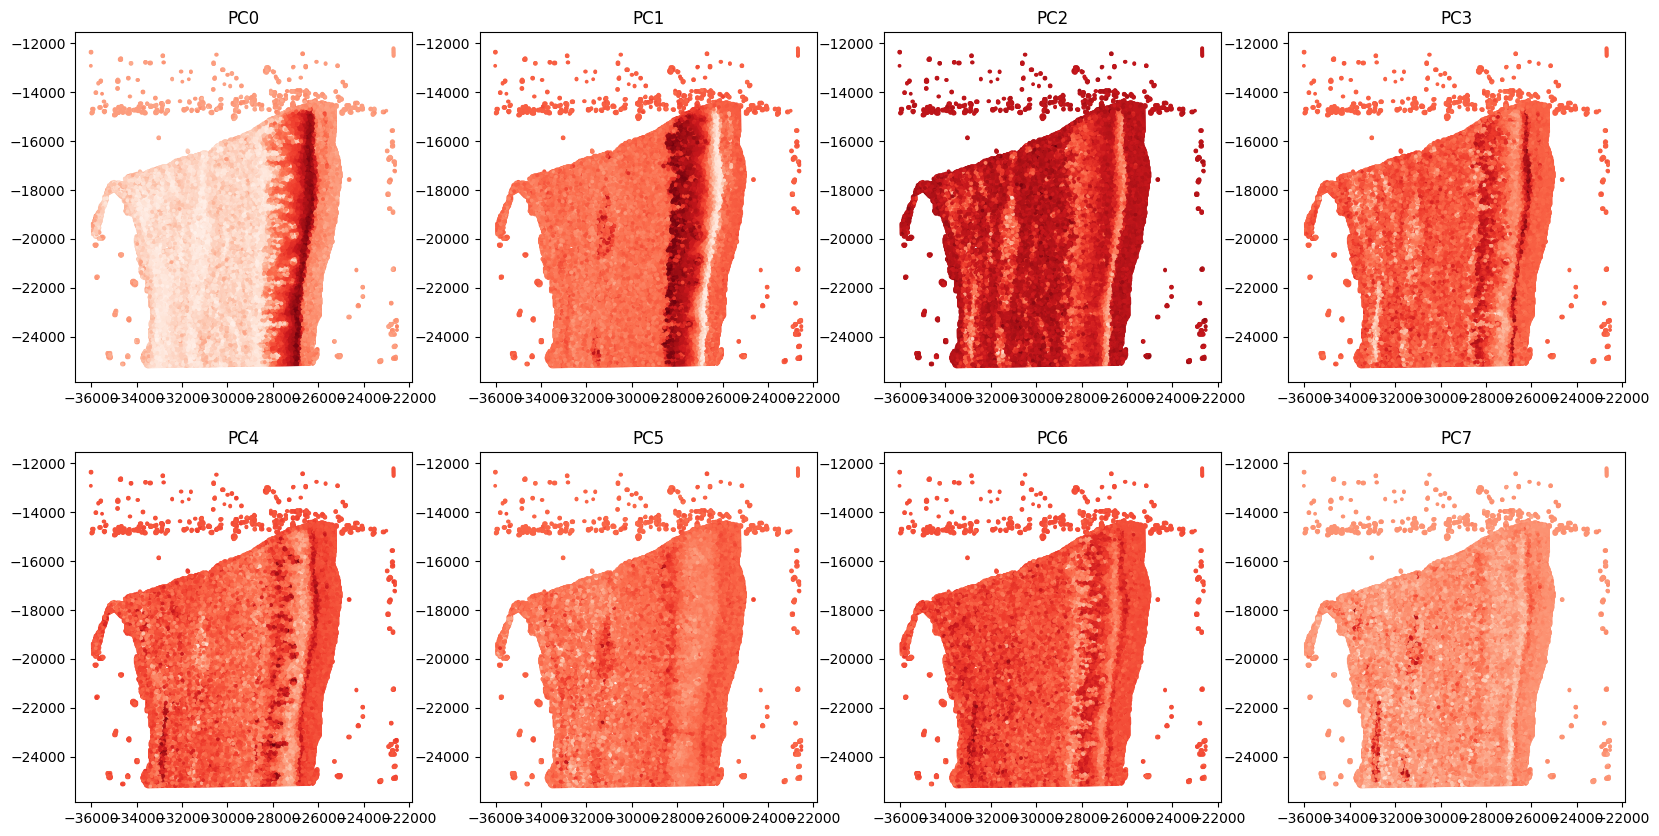

In [4]:
# visualize top GLM-PCs
rotated_coords=dp_related.rotate_by_theta(coords_mat, -np.pi/2)
R=2
C=4
fig,axs=plt.subplots(R,C,figsize=(20,10))
for r in range(R):
    for c in range(C):
        i=r*C+c
        axs[r,c].scatter(rotated_coords[:,0], rotated_coords[:,1], c=A[:,i],cmap='Reds',s=3)
        axs[r,c].set_title(f'PC{i}')

In [5]:
path_to_glmpca='skin_A1_16um_data/glmpca.npy'
path_to_coords='skin_A1_16um_data/coords_mat.npy'

A=np.load(path_to_glmpca) # GLM-PCA results used in manuscript
S=np.load(path_to_coords)

# z-score normalize S and A
S_torch, A_torch = neural_net.load_rescale_input_data(S,A)

In [6]:
isodepth_arch=[20,20] # architecture for isodepth neural network d(x,y) : R^2 -> R 
expression_fn_arch=[20,20] # architecture for 1-D expression function h(w) : R -> R^G

num_epochs = 10000 # number of epochs to train NN (NOTE: it is sometimes beneficial to train longer)
checkpoint = 500 # save model after number of epochs = multiple of checkpoint
out_dir='skin_A1_16um_data_outputs' # folder to save model runs
optimizer = "adam"
num_restarts=30
device='cpu' # change to 'cpu' if you don't have a GPU

######################################

seed_list=range(num_restarts)
for seed in seed_list:
    print(f'training neural network for seed {seed}')
    out_dir_seed=f"{out_dir}/rep{seed}"
    os.makedirs(out_dir_seed, exist_ok=True)
    mod, loss_list = neural_net.train(S_torch, A_torch,
                          S_hidden_list=isodepth_arch, A_hidden_list=expression_fn_arch, 
                          epochs=num_epochs, checkpoint=checkpoint, device=device,
                          save_dir=out_dir_seed, optim=optimizer, seed=seed, save_final=True)

training neural network for seed 0
Training on device: cpu
epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000
epoch: 2500
epoch: 3000
epoch: 3500
epoch: 4000
epoch: 4500
epoch: 5000
epoch: 5500
epoch: 6000
epoch: 6500
epoch: 7000
epoch: 7500
epoch: 8000
epoch: 8500
epoch: 9000
epoch: 9500
training neural network for seed 1
Training on device: cpu
epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000
epoch: 2500
epoch: 3000
epoch: 3500
epoch: 4000
epoch: 4500
epoch: 5000
epoch: 5500
epoch: 6000
epoch: 6500
epoch: 7000
epoch: 7500
epoch: 8000
epoch: 8500
epoch: 9000
epoch: 9500
training neural network for seed 2
Training on device: cpu
epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000
epoch: 2500
epoch: 3000
epoch: 3500
epoch: 4000
epoch: 4500
epoch: 5000
epoch: 5500
epoch: 6000
epoch: 6500
epoch: 7000
epoch: 7500
epoch: 8000
epoch: 8500
epoch: 9000
epoch: 9500
training neural network for seed 3
Training on device: cpu
epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000


In [7]:
import torch
import types
import gaston.process_NN_output as process_NN_output

_orig_load = torch.load

def _load_wo(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    kwargs.setdefault('map_location', 'cpu')
    return _orig_load(*args, **kwargs)

torch.load = _load_wo

try:
    gaston_model, A, S = process_NN_output.process_files('skin_A1_16um_data_outputs')
    counts_mat=np.load('skin_A1_16um_data/counts_mat.npy',allow_pickle=True)
    coords_mat=np.load('skin_A1_16um_data/coords_mat.npy',allow_pickle=True)
    gene_labels=np.load('skin_A1_16um_data/gene_labels.npy',allow_pickle=True)
finally:
    torch.load = _orig_load



best model: skin_A1_16um_data_outputs/rep29


Kneedle number of domains: 5


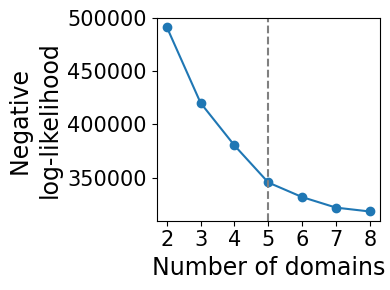

In [8]:
model_selection.plot_ll_curve(gaston_model, A, S, max_domain_num=8, start_from=2,num_buckets=100)

In [15]:
num_layers=3
gaston_isodepth, gaston_labels=dp_related.get_isodepth_labels(gaston_model,A,S,num_layers)

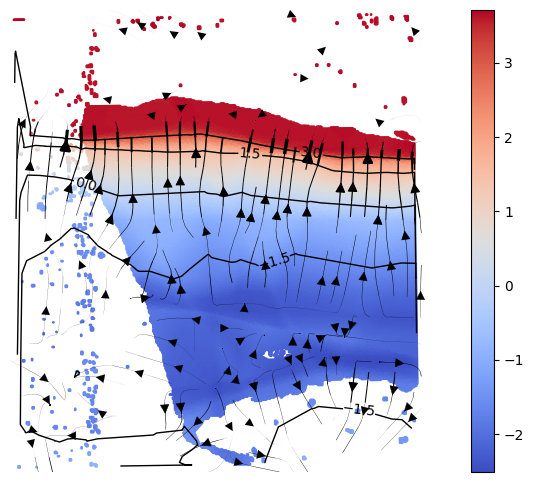

In [25]:
show_streamlines=True
arrowsize=1.5

cluster_plotting.plot_isodepth(gaston_isodepth, S, gaston_model, figsize=(7,6), s=1,streamlines=show_streamlines, arrowsize=arrowsize)

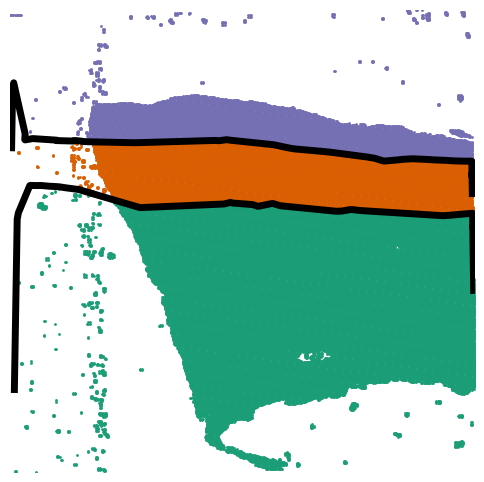

In [24]:
cluster_plotting.plot_clusters(gaston_labels, S, figsize=(6,6), s=1, lgd=False, show_boundary=True, gaston_isodepth=gaston_isodepth, boundary_lw=5)

In [21]:
umi_thresh = 2000 # only analyze genes with at least 2000 total UMIs
idx_kept, gene_labels_idx=filter_genes.filter_genes(counts_mat, gene_labels, 
                                       umi_threshold=umi_thresh, 
                                       exclude_prefix=['MT-'])
print(f'{len(idx_kept)} genes kept')

3808 genes kept


In [ ]:
import numpy as np
from gaston.segmented_fit import segmented_poisson_regression
from gaston import binning_and_plotting

# ========= 你已有的变量 =========
# counts_mat: 原始 counts
# gaston_labels: 每个 spot 的 label（可不是连续整数）
# gaston_isodepth: 每个 spot 的 isodepth
# gene_labels: 每个基因的名字
# idx_kept: 你用 filter_genes.filter_genes(umi_thresh=2000, exclude_prefix=['MT-']) 得到的“基因索引/掩码”

# ========= 可选阈值 =========
spot_exposure_threshold = None   # 例如 100 或 None
gene_umi_threshold_second = None # 若你想在 2000 之外再做一次基因过滤，可填数字；否则 None

# ========= 工具函数 =========
def coerce_indices(mask_or_idx, n):
    arr = np.asarray(mask_or_idx)
    if arr.dtype == bool:
        if arr.size != n:
            raise ValueError(f"布尔掩码长度 {arr.size} 与 n={n} 不一致")
        return np.where(arr)[0]
    return arr.astype(int)

def orient_to_genes_by_spots(counts, gene_count, spot_count):
    """把 counts 变成 (G, N)"""
    if counts.shape == (gene_count, spot_count):
        return counts
    if counts.shape == (spot_count, gene_count):
        return counts.T
    if counts.shape[0] == gene_count:
        return counts
    if counts.shape[1] == gene_count:
        return counts.T
    raise ValueError(f"无法判定 counts 朝向: {counts.shape}, genes={gene_count}, spots={spot_count}")

def strong_align_GxN(counts_GN, labels, isodepth, spot_exposure_threshold=None):
    """强力对齐为 (G, N)，labels 压缩为 0..L-1，剔除 NaN/Inf 与曝光<=0 的列"""
    C = np.asarray(counts_GN)
    Lb = np.asarray(labels)
    Iso = np.asarray(isodepth)

    # 步骤1：统一长度
    Nmin = min(C.shape[1], Lb.shape[0], Iso.shape[0])
    if (C.shape[1] != Nmin) or (Lb.shape[0] != Nmin) or (Iso.shape[0] != Nmin):
        C = C[:, :Nmin]
        Lb = Lb[:Nmin]
        Iso = Iso[:Nmin]

    # 步骤2：列过滤
    exposure = C.sum(axis=0)
    valid = np.isfinite(exposure) & (exposure > 0) & np.isfinite(Lb.astype(float)) & np.isfinite(Iso)
    if spot_exposure_threshold is not None:
        valid &= (exposure >= spot_exposure_threshold)

    C = C[:, valid]
    Lb = Lb[valid]
    Iso = Iso[valid]

    # 步骤3：压缩 labels 到 0..L-1
    _, Lb_idx = np.unique(Lb, return_inverse=True)

    return C, Lb_idx.astype(int), Iso

# ========= 主流程 =========
# 1) 统一朝向到 (G, N)
gene_count = len(gene_labels)
spot_count = len(gaston_labels)
counts = orient_to_genes_by_spots(np.asarray(counts_mat), gene_count, spot_count)

# 2) 基因过滤（用你已有的 idx_kept）
gene_idx = coerce_indices(idx_kept, n=counts.shape[0])
counts_g = counts[gene_idx, :]
gene_labels_g = np.asarray(gene_labels)[gene_idx]

# （可选）二次基因过滤（如果你还想在 2000 基础上再加一层）
if gene_umi_threshold_second is not None:
    gene_totals = counts_g.sum(axis=1)
    gene_mask2 = gene_totals >= gene_umi_threshold_second
    counts_g = counts_g[gene_mask2, :]
    gene_labels_g = gene_labels_g[gene_mask2]

# 3) 数值清洗
counts_g = np.nan_to_num(counts_g, nan=0.0, posinf=0.0, neginf=0.0)

# 4) 强力对齐（按列：labels/isodepth/exposure）
counts_ok, labels_ok, isodepth_ok = strong_align_GxN(
    counts_g, gaston_labels, gaston_isodepth, spot_exposure_threshold=spot_exposure_threshold
)

G, N = counts_ok.shape
print(f"[Aligned] counts_ok: (genes, spots) = {counts_ok.shape}; labels groups={len(np.unique(labels_ok))}")

# 5) 计算每个 spot 的总 UMI（注意：axis=0）
totalumi = counts_ok.sum(axis=0)  # 形状 (N,)

# 6) 直接调用 segmented_poisson_regression（绕过 pw_linear_fit）
#    这里的 L 是 label 的数量（分区数）
L = int(labels_ok.max()) + 1 if len(labels_ok) else 0

# 可选：正则项 alpha（对应原函数的 reg）；没有就 0
reg_alpha = 0.0

s0_mat, i0_mat, s1_mat, i1_mat, pv_mat = segmented_poisson_regression(
    counts_ok,      # (G, N)
    totalumi,       # (N,)
    labels_ok,      # (N,) 且取值 0..L-1
    isodepth_ok,    # (N,)
    L,              # 区域数
    reg=reg_alpha
)

print("[Done] segmented_poisson_regression 完成")
print("s0_mat / i0_mat / s1_mat / i1_mat / pv_mat shapes:",
      s0_mat.shape, i0_mat.shape, s1_mat.shape, i1_mat.shape, pv_mat.shape)

counts_for_binning = counts_ok.T  # 形状: (spots, genes)

# 2) 基因选择掩码（长度=基因数=counts_for_binning.shape[1]）
idx_kept_genes_for_plot = np.ones(counts_for_binning.shape[1], dtype=bool)
# 如果你想再按基因阈值画图，这里改成相应掩码即可

# 3) 调用 bin_data
binning_output = binning_and_plotting.bin_data(
    counts_for_binning,   # (spots, genes) ✅
    labels_ok,            # (spots,)
    isodepth_ok,          # (spots,)
    None,                 # cell_type_df
    gene_labels_g,        # (genes,)
    idx_kept=idx_kept_genes_for_plot,  # ← 基因维度的掩码/索引
    num_bins=15,
    umi_threshold=0       # 传个数值占位；因为我们已经提供了 idx_kept，不会走内部阈值分支
)

# 8) 可选：把结果打包成你习惯的字典（模拟 pw_fit_dict 的核心输出）
pw_fit_dict_like = {
    "s0_mat": s0_mat,
    "i0_mat": i0_mat,
    "s1_mat": s1_mat,
    "i1_mat": i1_mat,
    "pv_mat": pv_mat,
    "labels": labels_ok,
    "isodepth": isodepth_ok,
    "gene_labels": gene_labels_g
}


[Aligned] counts_ok: (genes, spots) = (3808, 77953); labels groups=3


 24%|██▎       | 903/3808 [00:10<00:31, 90.86it/s]/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/gaston/segmented_fit.py:138: RuntimeWarning: divide by zero encountered in log
  return np.sum(y * np.log(lam) - lam)
/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/gaston/segmented_fit.py:138: RuntimeWarning: invalid value encountered in multiply
  return np.sum(y * np.log(lam) - lam)
 35%|███▌      | 1340/3808 [00:15<00:28, 86.00it/s]/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y

[Done] segmented_poisson_regression 完成
s0_mat / i0_mat / s1_mat / i1_mat / pv_mat shapes: (3808, 3) (3808, 3) (3808, 3) (3808, 3) (3808, 3)


In [37]:
from gaston import spatial_gene_classification
import numpy as np

def make_pw_fit_dict_compat(s0_mat, i0_mat, s1_mat, i1_mat, pv_mat,
                            labels, isodepth, gene_labels):
    G = s0_mat.shape[0]
    d = {
        # 主矩阵
        "s0_mat": s0_mat,
        "i0_mat": i0_mat,
        "s1_mat": s1_mat,   # 带 isodepth 的斜率
        "i1_mat": i1_mat,
        "pv_mat": pv_mat,

        # 常见别名
        "slope0_mat": s0_mat,
        "intercept0_mat": i0_mat,
        "slope1_mat": s1_mat,
        "intercept1_mat": i1_mat,
        "pval_mat": pv_mat,

        # spot 级元数据
        "labels":           np.asarray(labels).astype(int),
        "gaston_labels":    np.asarray(labels).astype(int),
        "isodepth":         np.asarray(isodepth),
        "gaston_isodepth":  np.asarray(isodepth),

        # 基因信息
        "gene_labels": np.asarray(gene_labels),
        "idx_kept":    np.arange(G, dtype=int),

        # 供 spatial_gene_classification 使用：
        # 位置约定： (slope_mat_all, intercept_mat_all, discont_mat, placeholder)
        "all_cell_types": (s1_mat, i1_mat, pv_mat, None),
    }
    return d

pw_fit_dict = make_pw_fit_dict_compat(
    s0_mat, i0_mat, s1_mat, i1_mat, pv_mat,
    labels_ok, isodepth_ok, gene_labels_g
)

# 现在再调用：
discont_genes_layer = spatial_gene_classification.get_discont_genes(
    pw_fit_dict, binning_output, q=0.95
)
cont_genes_layer = spatial_gene_classification.get_cont_genes(
    pw_fit_dict, binning_output, q=0.8
)

print("OK ✓", 
      "discont keys:", list(discont_genes_layer.keys()), 
      "cont keys:", list(cont_genes_layer.keys()))


OK ✓ discont keys: ['KLHL21', 'EXOSC10', 'PINK1', 'WASF2', 'ZMYM4', 'PSMB2', 'ZC3H12A', 'MEAF6', 'YBX1', 'ELOVL1', 'PRDX1', 'JUN', 'CTBS', 'ZNHIT6', 'SELENOF', 'COL11A1', 'RAP1A', 'TXNIP', 'SETDB1', 'PSMD4', 'FLG', 'UBE2Q1', 'ZBTB7B', 'KHDC4', 'SSR2', 'PEA15', 'CREG1', 'SFT2D2', 'RABGAP1L', 'IER5', 'CYB5R1', 'TMEM183A', 'MAPKAPK2', 'EPHX1', 'GNPAT', 'SH3YL1', 'NCOA1', 'OST4', 'RHOQ', 'TPRKB', 'DGUOK', 'RNF181', 'IGKC', 'CNOT11', 'RNF149', 'ACTR3', 'PLA2R1', 'STK39', 'MREG', 'TUBA4A', 'DNAJB2', 'CUL3', 'MFF', 'AGFG1', 'SETD5', 'UBE2E1', 'PDCD6IP', 'NBEAL2', 'SEMA3F', 'ALAS1', 'TWF2', 'CGGBP1', 'CDV3', 'SLC25A36', 'TM4SF1', 'RAP2B', 'NMD3', 'ACAP2', 'NCBP2', 'MRFAP1L1', 'DCAF16', 'FAM114A1', 'SMIM14', 'FIP1L1', 'EXOC1', 'TMPRSS11E', 'USO1', 'BMP2K', 'RAP1GDS1', 'MCUB', 'FAM160A1', 'ARFIP1', 'MAP3K1', 'MAST4', 'CERT1', 'SCAMP1', 'MAN2A1', 'NREP', 'SEPTIN8', 'DDX46', 'UBE2D2', 'YIPF5', 'NDST1', 'CLINT1', 'WWC1', 'TMED9', 'DUSP22', 'SLC22A23', 'MCUR1', 'ATXN1', 'RNF144B', 'TUBB', 'CSNK2B', 

In [ ]:
discont_genes_layer

defaultdict(list,
            {'KLHL21': [1],
             'EXOSC10': [0],
             'PINK1': [1],
             'WASF2': [1],
             'ZMYM4': [0],
             'PSMB2': [0],
             'ZC3H12A': [1],
             'MEAF6': [0],
             'YBX1': [0],
             'ELOVL1': [0],
             'PRDX1': [0],
             'JUN': [1],
             'CTBS': [0],
             'ZNHIT6': [0],
             'SELENOF': [0],
             'COL11A1': [1],
             'RAP1A': [1],
             'TXNIP': [1],
             'SETDB1': [0],
             'PSMD4': [0],
             'FLG': [0],
             'UBE2Q1': [0],
             'ZBTB7B': [1],
             'KHDC4': [0],
             'SSR2': [0],
             'PEA15': [1],
             'CREG1': [0],
             'SFT2D2': [1],
             'RABGAP1L': [0],
             'IER5': [1],
             'CYB5R1': [1],
             'TMEM183A': [0],
             'MAPKAPK2': [0],
             'EPHX1': [0],
             'GNPAT': [0],
             'SH3YL1

In [39]:
cont_genes_layer

defaultdict(list,
            {'NOC2L': [2],
             'PLEKHN1': [0],
             'AGRN': [1],
             'MXRA8': [1, 2],
             'VWA1': [0],
             'MIB2': [0],
             'MEGF6': [1, 2],
             'LRRC47': [2],
             'PLEKHG5': [0],
             'ERRFI1': [0],
             'ENO1': [0],
             'CLSTN1': [0, 1],
             'CTNNBIP1': [0],
             'SRM': [1, 2],
             'MAD2L2': [1, 2],
             'MFN2': [0],
             'PDPN': [0, 1, 2],
             'EFHD2': [1],
             'EPHA2': [1],
             'MFAP2': [1, 2],
             'PINK1': [0],
             'ECE1': [0, 1, 2],
             'C1QA': [1, 2],
             'C1QC': [1, 2],
             'C1QB': [1, 2],
             'ZNF436': [2],
             'ID3': [1],
             'GRHL3': [0, 2],
             'RCAN3': [0],
             'CRYBG2': [0],
             'SFN': [0, 2],
             'NUDC': [2],
             'SYTL1': [0],
             'MAP3K6': [0],
             'LAPTM5':

In [40]:
len(cont_genes_layer), len(discont_genes_layer)

(1485, 375)

gene SPARC: continuous gradient in domain(s) [0, 1, 2]


/var/folders/pm/_db3z8953vb1gtk99jkk_sb80000gn/T/ipykernel_6759/2181447256.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  domain_colors = plt.cm.get_cmap('Dark2', 8).colors  # Returns a tuple of RGBA tuples


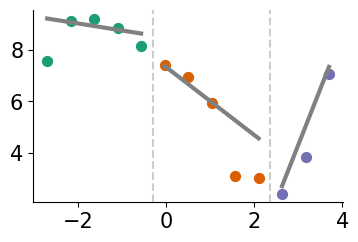

In [41]:
gene_name='SPARC'

if gene_name in discont_genes_layer:
    print(f'gene {gene_name}: discontinuous jump after domain(s) {discont_genes_layer[gene_name]}') 
if gene_name in cont_genes_layer:
    print(f'gene {gene_name}: continuous gradient in domain(s) {cont_genes_layer[gene_name]}')

domain_colors = plt.cm.get_cmap('Dark2', 8).colors  # Returns a tuple of RGBA tuples
domain_colors = list(domain_colors)  # Convert to list if needed

# display log CPM (if you want to do CP500, set offset=500)
offset=10**6

binning_and_plotting.plot_gene_pwlinear(gene_name, pw_fit_dict, gaston_labels, gaston_isodepth, 
                                        binning_output, cell_type_list=None, pt_size=50, colors=domain_colors,
                                        linear_fit=True, ticksize=15, figsize=(4,2.5), offset=offset, lw=3,
                                       domain_boundary_plotting=True)

/Users/siyuanzhao/anaconda3/envs/gaston/lib/python3.10/site-packages/gaston/binning_and_plotting.py:324: RuntimeWarning: invalid value encountered in divide
  expression = np.log((raw_expression / exposure) * offset + 1)


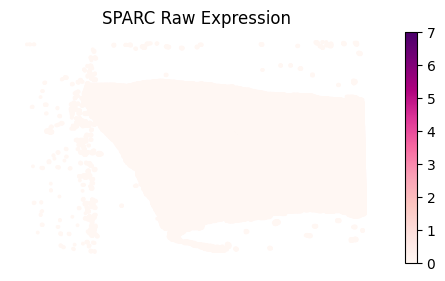

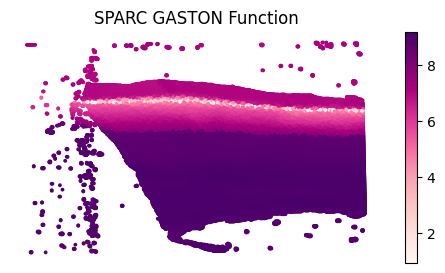

In [42]:
reload(binning_and_plotting)
binning_and_plotting.plot_gene_raw(gene_name, gene_labels_idx, counts_mat, S, vmin=0,vmax=7, 
                                   figsize=(6,3),s=3)
plt.title(f'{gene_name} Raw Expression')
binning_and_plotting.plot_gene_function(gene_name, S, pw_fit_dict, gaston_labels, gaston_isodepth, 
                                        binning_output, figsize=(6,3),s=3)
plt.title(f'{gene_name} GASTON Function')
plt.show()